In [3]:
##Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
##Load Dataset
df = pd.read_csv("data/Ecommerce.csv")

In [6]:
##Explore Dataset
df.head()
df.info()
df.shape
df.columns
df.describe()



<class 'pandas.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 29 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   customer_id              25000 non-null  int64  
 1   session_id               25000 non-null  int64  
 2   visit_date               25000 non-null  str    
 3   device_type              25000 non-null  int64  
 4   user_type                25000 non-null  int64  
 5   marketing_channel        25000 non-null  int64  
 6   product_id               25000 non-null  int64  
 7   product_category         25000 non-null  int64  
 8   unit_price               25000 non-null  float64
 9   quantity                 25000 non-null  int64  
 10  discount_percent         25000 non-null  int64  
 11  discount_amount          25000 non-null  float64
 12  revenue                  25000 non-null  float64
 13  pages_viewed             25000 non-null  int64  
 14  time_on_site_sec         25000 no

,customer_id,session_id,device_type,user_type,marketing_channel,product_id,product_category,unit_price,quantity,discount_percent,...,rating,review_text,review_helpful_votes,payment_method,visit_day,visit_month,visit_weekday,visit_season,revenue_normalized,location
count,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.00000,...,25000.00000,25000.00000,25000.00000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.00000
mean,5479.930600,12499.500000,0.705040,0.551280,2.514040,449.107000,3.495240,782.319010,2.489040,8.99880,...,3.94800,1.67488,5.52080,2.483160,15.714520,6.510520,2.980800,1.504400,0.051290,111.70692
std,2593.544596,7217.022701,0.639543,0.497373,1.704934,259.513787,2.285053,476.612168,1.114563,9.26364,...,0.54047,1.98673,12.33629,1.709501,8.796338,3.457925,1.992554,1.117475,0.129591,65.07079
min,1000.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,50.050000,1.000000,0.00000,...,1.00000,0.00000,0.00000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.00000
25%,3234.000000,6249.750000,0.000000,0.000000,1.000000,225.000000,2.000000,395.222500,1.000000,0.00000,...,4.00000,1.00000,0.00000,1.000000,8.000000,3.000000,1.000000,1.000000,0.000000,55.00000
50%,5482.000000,12499.500000,1.000000,1.000000,2.000000,448.000000,4.000000,691.725000,2.000000,10.00000,...,4.00000,1.00000,0.00000,2.000000,16.000000,7.000000,3.000000,2.000000,0.000000,111.00000
75%,7715.000000,18749.250000,1.000000,1.000000,4.000000,675.000000,5.000000,1096.842500,3.000000,15.00000,...,4.00000,1.00000,0.00000,4.000000,23.000000,10.000000,5.000000,3.000000,0.000000,169.00000
max,9998.000000,24999.000000,2.000000,1.000000,5.000000,898.000000,7.000000,1999.830000,4.000000,30.00000,...,5.00000,10.00000,49.00000,5.000000,31.000000,12.000000,6.000000,3.000000,1.000000,224.00000


In [7]:
##Check Missing Values
df.isnull().sum()

customer_id                0
session_id                 0
visit_date                 0
device_type                0
user_type                  0
marketing_channel          0
product_id                 0
product_category           0
unit_price                 0
quantity                   0
discount_percent           0
discount_amount            0
revenue                    0
pages_viewed               0
time_on_site_sec           0
added_to_cart              0
purchased                  0
cart_abandoned             0
rating                     0
review_text                0
review_helpful_votes       0
payment_method             0
visit_day                  0
visit_month                0
visit_weekday              0
visit_season               0
session_duration_bucket    0
revenue_normalized         0
location                   0
dtype: int64

In [8]:
##Remove Duplicates
df.drop_duplicates(inplace=True)

In [11]:
##Encode Categorical Variables
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

categorical_columns = [
    "device_type",
    "user_type",
    "marketing_channel",
    "product_category",
    "payment_method",
    "visit_day",
    "visit_weekday",
    "visit_season",
    "session_duration_bucket",
    "location"
]

for col in categorical_columns:
    df[col] = encoder.fit_transform(df[col].astype(str))

In [12]:
##Check Data Types
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 29 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   customer_id              25000 non-null  int64  
 1   session_id               25000 non-null  int64  
 2   visit_date               25000 non-null  str    
 3   device_type              25000 non-null  int64  
 4   user_type                25000 non-null  int64  
 5   marketing_channel        25000 non-null  int64  
 6   product_id               25000 non-null  int64  
 7   product_category         25000 non-null  int64  
 8   unit_price               25000 non-null  float64
 9   quantity                 25000 non-null  int64  
 10  discount_percent         25000 non-null  int64  
 11  discount_amount          25000 non-null  float64
 12  revenue                  25000 non-null  float64
 13  pages_viewed             25000 non-null  int64  
 14  time_on_site_sec         25000 no

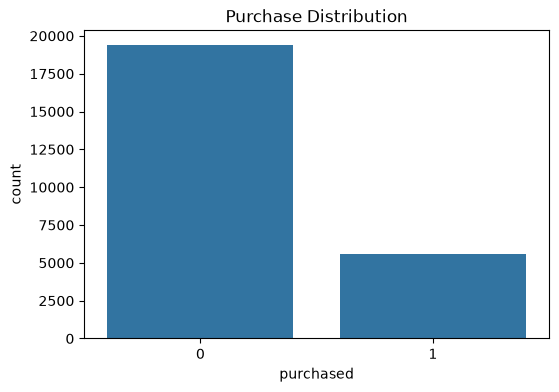

In [13]:
##exploratory Data Analysis (EDA)
##Purchase Distribution
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))
sns.countplot(x="purchased", data=df)
plt.title("Purchase Distribution")
plt.show()

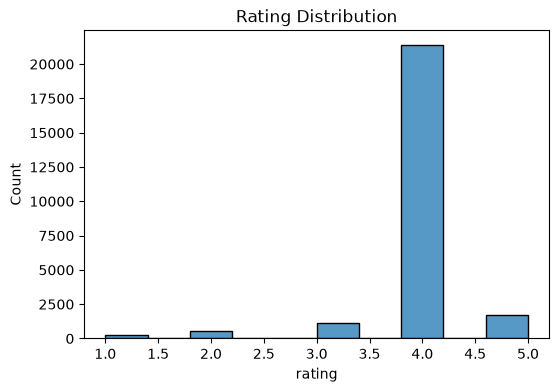

In [14]:
##Rating Distribution
plt.figure(figsize=(6,4))
sns.histplot(df["rating"], bins=10)
plt.title("Rating Distribution")
plt.show()

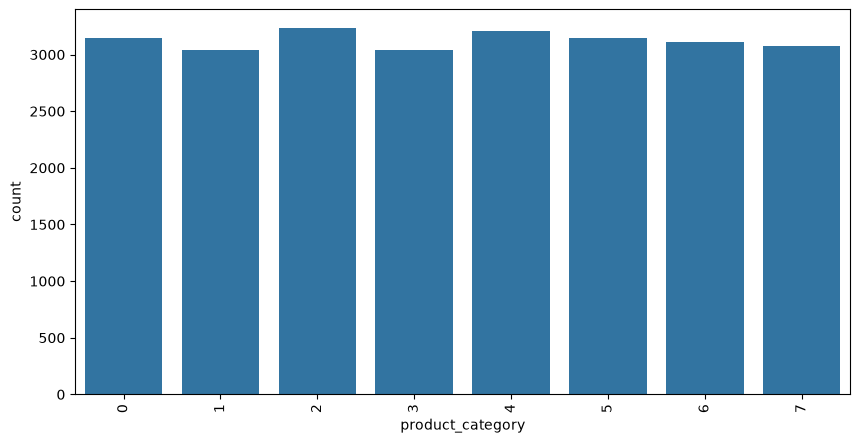

In [15]:
##Product Category Distribution
plt.figure(figsize=(10,5))
sns.countplot(x="product_category", data=df)
plt.xticks(rotation=90)
plt.show()

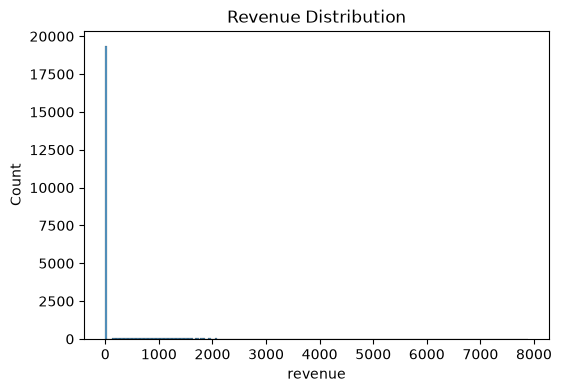

In [16]:
##Revenue Distribution
plt.figure(figsize=(6,4))
sns.histplot(df["revenue"])
plt.title("Revenue Distribution")
plt.show()

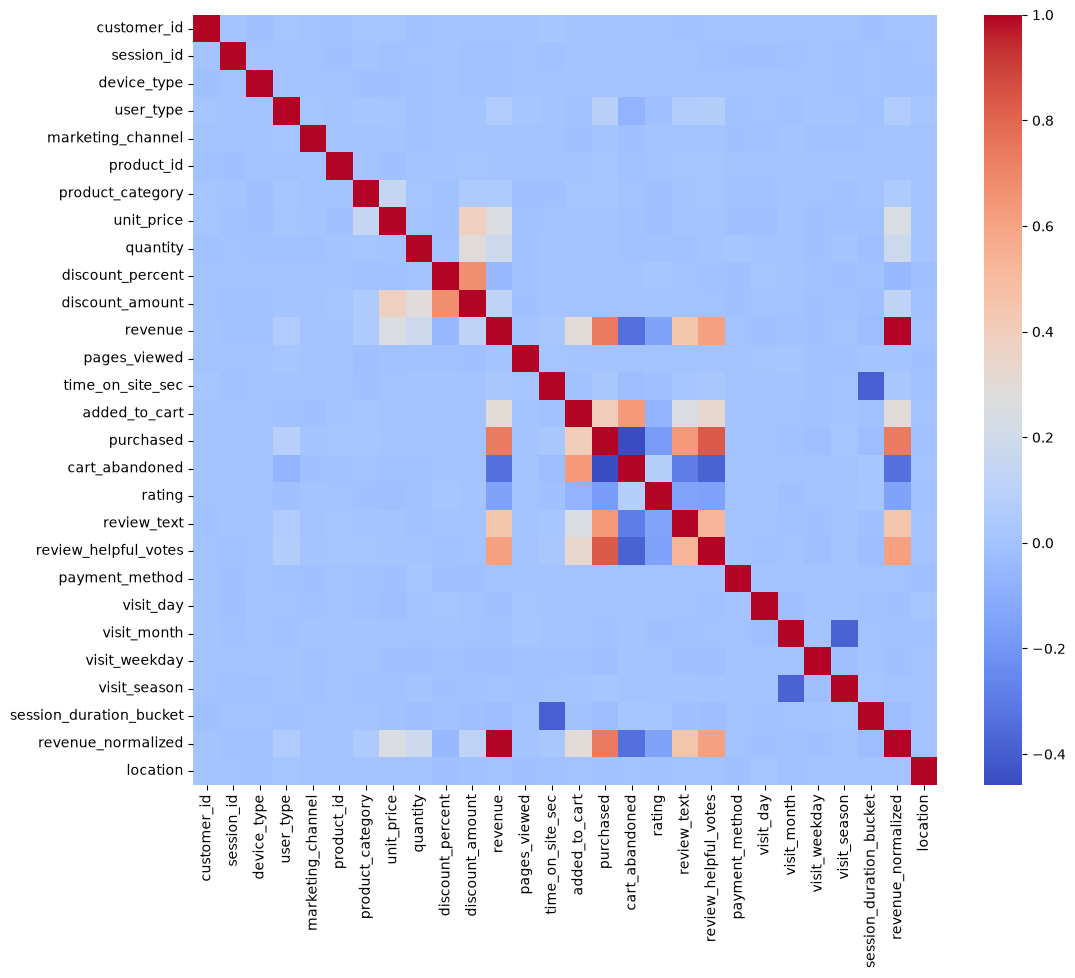

In [17]:
##Correlation Heatmap
plt.figure(figsize=(12,10))
sns.heatmap(df.corr(numeric_only=True), annot=False, cmap="coolwarm")
plt.show()


In [18]:
##Linear Regression
##Features
X = df[
[
    "unit_price",
    "quantity",
    "discount_percent",
    "pages_viewed",
    "time_on_site_sec",
    "revenue"
]
]

In [19]:
##Target
y = df["rating"]

In [20]:
##Train-Test Split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [21]:
##Linear Regression
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](6,)","[ 0. , 0.01, 0. , 0. ,-0. ,-0. ]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](6,)","['unit_price','quantity','discount_percent','pages_viewed', 'time_on_site_sec','revenue']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,3.936
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,6
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(6)


In [22]:
##Prediction
prediction = model.predict(X_test)

In [23]:
##Evaluation
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

print("MAE :", mean_absolute_error(y_test, prediction))
print("RMSE :", np.sqrt(mean_squared_error(y_test, prediction)))
print("R2 :", r2_score(y_test, prediction))

MAE : 0.2174961059293966
RMSE : 0.5432406464985752
R2 : 0.026153988277993534


In [24]:
##Ridge Regression
from sklearn.linear_model import Ridge


In [25]:
ridge = Ridge(alpha=1.0)

In [26]:
ridge.fit(X_train, y_train)

,"alpha alpha: float or array-like of shape (n_targets,), default=1.0Constant that multiplies the L2 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Ridge` object is not advised.Instead, you should use the :class:`LinearRegression` object.If an array is passed, penalties are assumed to be specific to thetargets. Hence they must correspond in number.See :ref:`sphx_glr_auto_examples_linear_model_plot_ridge_coeffs.py`for an illustration of the effect of alpha on the model coefficients.",1.0
,"fit_intercept fit_intercept: bool, default=TrueWhether to fit the intercept for this model. If setto false, no intercept will be used in calculations(i.e. ``X`` and ``y`` are expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=NoneMaximum number of iterations for conjugate gradient solver.For 'sparse_cg' and 'lsqr' solvers, the default value is determinedby scipy.sparse.linalg. For 'sag' solver, the default value is 1000.For 'lbfgs' solver, the default value is 15000.",None
,"tol tol: float, default=1e-4The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for each solver:- 'svd': `tol` has no impact.- 'cholesky': `tol` has no impact.- 'sparse_cg': norm of residuals smaller than `tol`.- 'lsqr': `tol` is set as atol and btol of scipy.sparse.linalg.lsqr, which control the norm of the residual vector in terms of the norms of matrix and coefficients.- 'sag' and 'saga': relative change of coef smaller than `tol`.- 'lbfgs': maximum of the absolute (projected) gradient=max|residuals| smaller than `tol`... versionchanged:: 1.2 Default value changed from 1e-3 to 1e-4 for consistency with other linear models.",0.0001
,"solver solver: {'auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga', 'lbfgs'}, default='auto'Solver to use in the computational routines:- 'auto' chooses the solver automatically based on the type of data.- 'svd' uses a Singular Value Decomposition of X to compute the Ridge coefficients. It is the most stable solver, in particular more stable for singular matrices than 'cholesky' at the cost of being slower.- 'cholesky' uses the standard :func:`scipy.linalg.solve` function to obtain a closed-form solution.- 'sparse_cg' uses the conjugate gradient solver as found in :func:`scipy.sparse.linalg.cg`. As an iterative algorithm, this solver is more appropriate than 'cholesky' for large-scale data (possibility to set `tol` and `max_iter`).- 'lsqr' uses the dedicated regularized least-squares routine :func:`scipy.sparse.linalg.lsqr`. It is the fastest and uses an iterative procedure.- 'sag' uses a Stochastic Average Gradient descent, and 'saga' uses its improved, unbiased version named SAGA. Both methods also use an iterative procedure, and are often faster than other solvers when both n_samples and n_features are large. Note that 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`.- 'lbfgs' uses L-BFGS-B algorithm implemented in :func:`scipy.optimize.minimize`. It can be used only when `positive` is True.All solvers except 'svd' support both dense and sparse data. However, only'lsqr', 'sag', 'sparse_cg', and 'lbfgs' support sparse input when`fit_intercept` is True... versionadded:: 0.17 Stochastic Average Gradient descent solver... versionadded:: 0.19 SAGA solver.",'auto'
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.Only 'lbfgs' solver is supported in this case.",False
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag' or 'saga' 

In [27]:
ridge_pred = ridge.predict(X_test)

In [28]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

print("MAE:", mean_absolute_error(y_test, ridge_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, ridge_pred)))
print("R² Score:", r2_score(y_test, ridge_pred))

MAE: 0.21749598393802685
RMSE: 0.5432406531134505
R² Score: 0.026153964561543064


In [30]:
##Hyperparameter Tuning (Ridge Regression)
from sklearn.model_selection import GridSearchCV

In [31]:
params = {
    "alpha": [0.01, 0.1, 1, 10, 100]
}

In [32]:
grid = GridSearchCV(
    Ridge(),
    params,
    cv=5,
    scoring="r2"
)

grid.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Ridge()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'alpha': [0.01, 0.1, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'r2'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding mor

In [33]:
print("Best Parameters:", grid.best_params_)
print("Best Score:", grid.best_score_)

Best Parameters: {'alpha': 100}
Best Score: 0.022176655655579226


In [34]:
best_ridge = grid.best_estimator_

In [35]:
best_pred = best_ridge.predict(X_test)

In [36]:
print("MAE:", mean_absolute_error(y_test, best_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, best_pred)))
print("R² Score:", r2_score(y_test, best_pred))

MAE: 0.21748397027907868
RMSE: 0.5432413076510735
R² Score: 0.026151617832705365


In [38]:
##Logistic Regression
X = df[
[
    "unit_price",
    "quantity",
    "discount_percent",
    "pages_viewed",
    "time_on_site_sec",
    "rating",
    "revenue"
]
]

y = df["purchased"]

In [ ]:
##Train-Test Split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [40]:
##Train Logistic Regression
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(max_iter=1000)

log_model.fit(X_train, y_train)

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is '

In [42]:
##Prediction
log_pred = log_model.predict(X_test)

In [43]:
##Evaluate
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

print("Accuracy:", accuracy_score(y_test, log_pred))

print(classification_report(y_test, log_pred))

print(confusion_matrix(y_test, log_pred))

Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      3859
           1       1.00      1.00      1.00      1141

    accuracy                           1.00      5000
   macro avg       1.00      1.00      1.00      5000
weighted avg       1.00      1.00      1.00      5000

[[3859    0]
 [   0 1141]]


In [45]:
##Hyperparameter Tuning (Logistic Regression)
params = {
    "C": [0.01, 0.1, 1, 10],
    "solver": ["liblinear", "lbfgs"]
}

grid_log = GridSearchCV(
    LogisticRegression(max_iter=1000),
    params,
    cv=5,
    scoring="accuracy"
)

grid_log.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LogisticRegre...max_iter=1000)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [0.01, 0.1, ...], 'solver': ['liblinear', 'lbfgs']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Controls the verbosity of informa

In [46]:
print(grid_log.best_params_)
print(grid_log.best_score_)

{'C': 0.01, 'solver': 'liblinear'}
1.0


In [47]:
##K-Means Clustering
## Select Features
X_cluster = df[
    [
        "pages_viewed",
        "time_on_site_sec",
        "quantity",
        "revenue"
    ]
]

In [49]:
##Scale the Data
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X_cluster)

In [51]:
##Elbow Method
## Import KMeans
from sklearn.cluster import KMeans

In [53]:
##Calculate Inertia
inertia = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

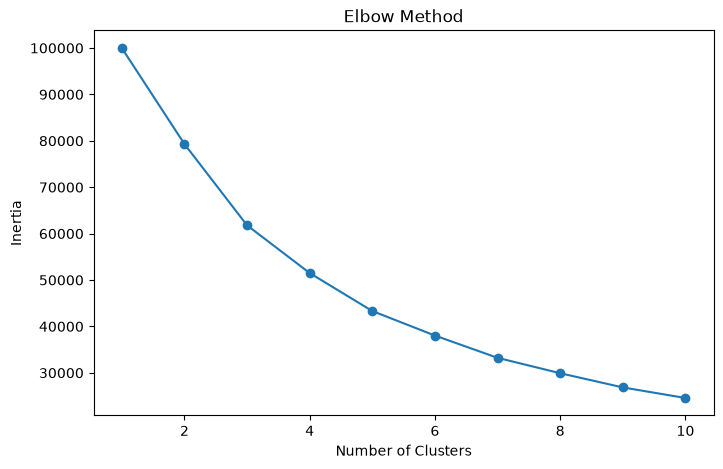

In [54]:
##Plot the Elbow Curve
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(range(1,11), inertia, marker="o")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

In [56]:
##Train the Final K-Means Model
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)

df["Cluster"] = kmeans.fit_predict(X_scaled)

In [57]:
##View Cluster Counts
print(df["Cluster"].value_counts())

Cluster
1    12207
2    10610
0     2183
Name: count, dtype: int64


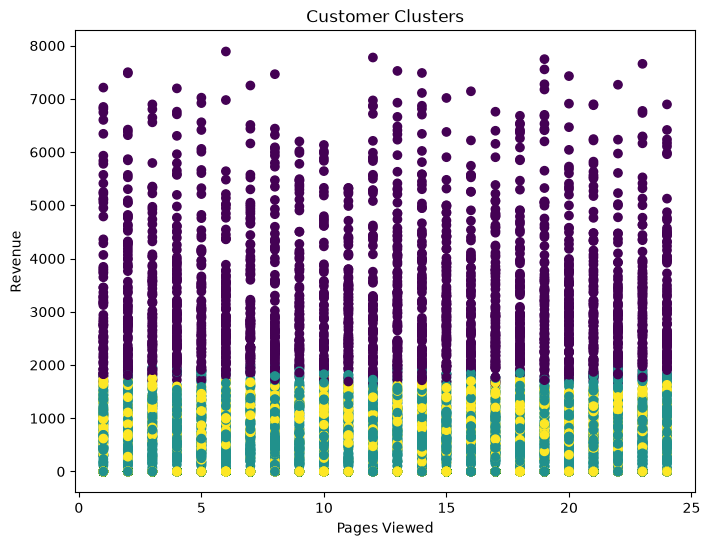

In [58]:
##Visualize Clusters
plt.figure(figsize=(8,6))

plt.scatter(
    df["pages_viewed"],
    df["revenue"],
    c=df["Cluster"]
)

plt.xlabel("Pages Viewed")
plt.ylabel("Revenue")
plt.title("Customer Clusters")

plt.show()

In [59]:
##Silhouette Score
from sklearn.metrics import silhouette_score

score = silhouette_score(X_scaled, df["Cluster"])

print("Silhouette Score:", score)

Silhouette Score: 0.2535074252998862


In [60]:
##Model Comparison
comparison = {
    "Model": [
        "Linear Regression",
        "Ridge Regression",
        "Logistic Regression",
        "K-Means"
    ],
    "Metric": [
        "R² Score",
        "R² Score",
        "Accuracy",
        "Silhouette Score"
    ],
    "Value": [
        r2_score(y_test, prediction),
        r2_score(y_test, best_pred),
        accuracy_score(y_test, log_pred),
        score
    ]
}

comparison_df = pd.DataFrame(comparison)

comparison_df

,Model,Metric,Value
0,Linear Regression,R² Score,-78.960728
1,Ridge Regression,R² Score,-78.960631
2,Logistic Regression,Accuracy,1.000000
3,K-Means,Silhouette Score,0.253507


In [61]:
##Save the Best Models
import pickle

with open("ridge_model.pkl", "wb") as f:
    pickle.dump(best_ridge, f)

with open("logistic_model.pkl", "wb") as f:
    pickle.dump(grid_log.best_estimator_, f)

with open("kmeans_model.pkl", "wb") as f:
    pickle.dump(kmeans, f)

with open("scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)
